In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import os
import struct
import math
import time
import sys
import utm

sys.path.append('..')


import lib.beta_functions as bf
from lib.beta_functions import read_spec, write_spec, write_beta_files, read_beta_files
import importlib

from tqdm import tqdm, trange


In [2]:

# Each .spec file needs a shead (general header info), ehead (event-specific
# header info) and a list of dicts representing each station

# this is the same shead as in the Ridgecrest 2019 multitaper .spec files
shead = {
    'ispec_method'  : 99,
    'ntwind'        : 150,
    'nf'            : 76,
    'twindoff'      : -0.05,
    'dt'            : 0.01,
    'df'            : 2.0 / 3.0
}

dt = shead['dt']
nf = shead['nf']
nt = shead['ntwind']
Fs = 1 / dt
Fn = Fs * 0.5

f = np.linspace(0, Fn, nf)



Generate a grid of synthetic stations


In [3]:
nstations_row = 11

slat_range = [3, 5]
slon_range = [-10, -8]



sg = np.meshgrid(
    np.linspace(slat_range[0], slat_range[1], nstations_row), 
    np.linspace(slon_range[0], slon_range[1], nstations_row)
)

sloc = np.array([el.flatten() for el in sg]).T

slat, slon = sloc[:, 0], sloc[:, 1]

nstations = len(slat)

# station + channel name
stype = 'XYZ'
stname = [str(el).zfill(3) for el in np.arange(nstations)]
loccode = ''
chnm = 'HHZ'

npts = 12001
tdif = -30.0
selev = 0

stations = pd.DataFrame(
    data = {
        'stname'        : stname,
        'loccode'       : loccode,
        'datasource'    : '',
        'sensor'        : '',
        'units'         : '', 
        'chnm'          : chnm, 
        'stype'         : stype, 
        'dva'           : '', 
        'pick1q'        : '', 
        'pick2q'        : '', 
        'pick3q'        : '', 
        'pick4q'        : '', 
        'pick1name'     : '', 
        'pick2name'     : '', 
        'pick3name'     : '', 
        'pick4name'     : '', 
        'ppolarity'     : '', 
        'problem'       : '', 
    }
)

# Compute eastings and northings of events
sx, sy, zn, zl = utm.from_latlon(
    slat, 
    slon
    )

print(zn, zl)


29 N


Generate events

2.000045356665827 5.999423210540342
-10.999936619925567 -7.000396290738976


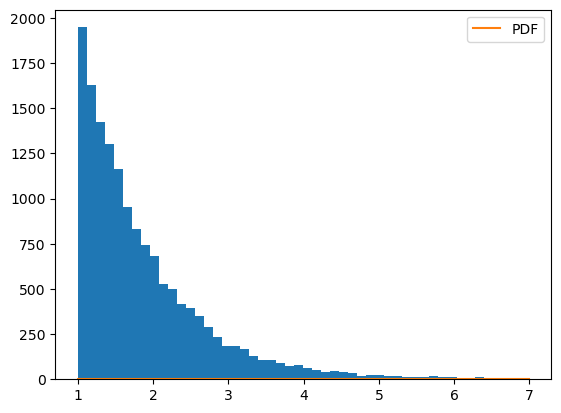

In [4]:
nevents = 15000
Mw_range = [1, 7]

qlat_range = [2, 6]
qlon_range = [-11, -7]

cuspid = np.arange(nevents)
numts = nstations
qmag1type = 'Mw'

rng = np.random.default_rng(seed=0)
possible_mags = np.arange(Mw_range[0], Mw_range[1], 0.01)
mags_pdf = np.power(10, 5 - 0.5*possible_mags)
mags_pdf = mags_pdf / np.sum(mags_pdf)

# perfect Gutenberg-Richter law - maybe try incomplete also?
qmag = rng.choice(possible_mags, size=nevents, p=mags_pdf, shuffle=False)

rng = np.random.default_rng(seed=1)
qlat = (rng.random([nevents]) * (np.diff(qlat_range))) + qlat_range[0]
qlon = (rng.random([nevents]) * (np.diff(qlon_range))) + qlon_range[0]

# generate random depths
rng = np.random.default_rng(seed=2)
qdep = rng.random([nevents]) * 18

print(min(qlat), max(qlat))
print(min(qlon), max(qlon))

plt.figure()
plt.hist(qmag, 50)
plt.plot(possible_mags, mags_pdf, label='PDF')

# plt.yscale('log')
plt.legend()
plt.show()



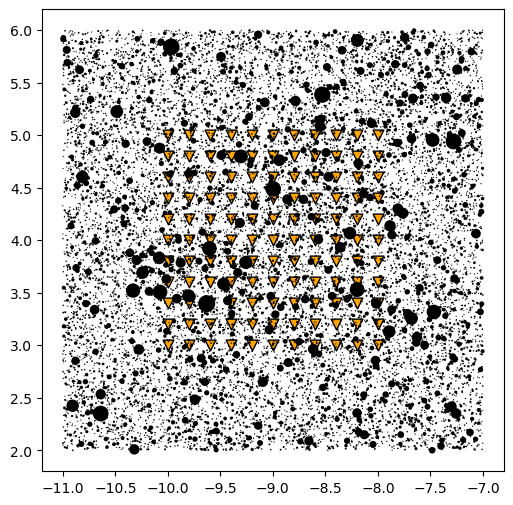

In [5]:


plt.figure(figsize=(6,6))
ax = plt.gca()
plt.scatter(slon, slat, c='orange', marker='v', edgecolor='k', s=60)
plt.scatter(qlon, qlat, c='k', s=(2.5**qmag), marker='.', edgecolors='none')
ax.set_aspect('equal')
plt.show()


Generate source parameters

29 N


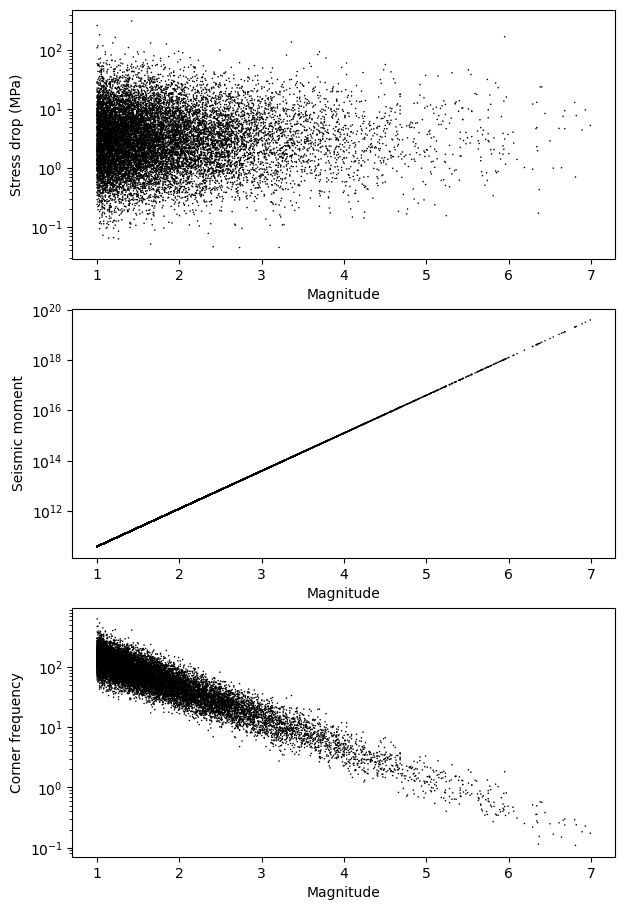

In [6]:
# self-similarity assumption
median_delsig = 3.0
k = 0.38
B = 3464.0

rng = np.random.default_rng(seed=3)
logdelsig = rng.normal(
    loc=np.log10(median_delsig), 
    scale=0.5, 
    size=nevents
)
delsig = np.power(10, logdelsig)

m0 = np.power(10, 1.5 * qmag + 9.1)

omega0 = m0 / (1E12)

fc = np.power((16.7) * (delsig*1E6 / m0), 1/3) * k * B

events = pd.DataFrame(
    data = {
        'cuspid'    : cuspid,
        'qlat'      : qlat,
        'qlon'      : qlon,
        'qdep'      : qdep,
        'qmag1'     : qmag, 
        'delsig'    : delsig,
        'm0'        : m0,
        'fc'        : fc,

    }
)

# Compute eastings and northings of events
qx, qy, zn, zl = utm.from_latlon(
    events['qlat'].values, 
    events['qlon'].values
    )
print(zn, zl)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(7,11))
ax1.scatter(qmag, delsig, c='k', s=5, edgecolors='none', marker='.')
ax1.set_xlabel("Magnitude")
ax1.set_ylabel("Stress drop (MPa)")
ax1.set_yscale('log')

ax2.scatter(qmag, m0, c='k', s=5, edgecolors='none', marker='.')
ax2.set_xlabel("Magnitude")
ax2.set_ylabel("Seismic moment")
ax2.set_yscale('log')

ax3.scatter(qmag, fc, c='k', s=5, edgecolors='none', marker='.')
ax3.set_xlabel("Magnitude")
ax3.set_ylabel("Corner frequency")
ax3.set_yscale('log')
plt.show()


Generate spectra and eheads for each event

In [7]:
t = 1
Q = 500
alpha = 6000

output_dir = "/Users/ivandevert/prog/spectral-falloff-ratio/example_data/synthetic_spec_files/"

rng = np.random.default_rng(seed=4)


s0 = np.empty([nevents, nf], dtype=float)

counter = trange(nevents, desc='Generating .spec files: ')
for i in counter:

    # estimate source spectrum
    # brune model
    s0[i,:] = omega0[i] / (1 + np.power((f / fc[i]), 2))


    ehead = {
        'efslabel': '',
        'datasource': '',
        'maxnumts': nstations,
        'numts': nstations,
        'cuspid': cuspid[i],
        'qtype': '',
        'qmag1type': 'Mw',
        'qmag2type': '',
        'qmag3type': '',
        'qmomenttype': '',
        'qlocqual': '',
        'qfocalqual': '',
        'qlat': qlat[i],
        'qlon': qlon[i],
        'qdep': qdep[i],
        'qsc': 0.0,
        'qmag1': qmag[i],
        'qmag2': 0.0,
        'qmag3': 0.0,
        'qmoment': 0.0,
        'qstrike': 0.0,
        'qdip': 0.0,
        'qrake': 0.0,
        'qyr': 0,
        'qmon': 0,
        'qdy': 0,
        'qhr': 0,
        'qmn': 0
    }


    spec = []
    for j in range(nstations):

        # calculate horizontal distance
        dist = np.sqrt((sx[j]-qx[i])**2 + (sy[j]-qy[i])**2) / 1000

        # estimate attenuation (Shearer 2019 eq. 6.83)
        atten = np.exp(-2 * np.pi * f / (2*alpha*Q))

        # synthetic spectrum record
        s2 = s0[i,:] * atten

        s1 = np.zeros(nf, dtype=float)

        # time series?
        x1 = (rng.random(nt) - 0.5 ) * 0.0001
        x2 = rng.random(nt) - 0.5
        # add noise?

        # construct sp dict
        sp = {
            'stname'        : stname[j],
            'loccode'       : loccode,
            'datasource'    : '',
            'sensor'        : '',
            'units'         : '',
            'chnm'          : chnm,
            'stype'         : stype,
            'dva'           : '',
            'pick1q'        : '',
            'pick2q'        : '',
            'pick3q'        : '',
            'pick4q'        : '',
            'pick1name'     : '',
            'pick2name'     : '',
            'pick3name'     : '',
            'pick4name'     : '',
            'ppolarity'     : '',
            'problem'       : '',
            'npts'          : 12001,
            'syr'           : 0,
            'smon'          : 0,
            'sdy'           : 0,
            'shr'           : 0,
            'smn'           : 0,
            'compazi'       : -99.0,
            'compang'       : -99.0,
            'gain'          : 1.0,
            'f1'            : -1.0,
            'f2'            : -1.0,
            'dt'            : dt,
            'ssc'           : 0.0,
            'tdif'          : -30.0,
            'slat'          : slat[j],
            'slon'          : slon[j],
            'selev'         : 0.0,
            'deldist'       : dist,
            'sazi'          : 0.0,
            'qazi'          : 0.0,
            'pick1'         : -99.0,
            'pick2'         : 0.0,
            'pick3'         : 0.0,
            'pick4'         : -99.0,
            'x1'            : x1,
            'x2'            : x2,
            's1'            : s1,
            's2'            : s2
        }

        spec += [sp]

    # output .spec file
    write_spec(output_dir + f"{cuspid[i]}.spec", ehead, shead, spec)
    
# save source parameters
events.to_pickle('data/syn_cat.pkl')



Generating .spec files: 100%|██████████| 15000/15000 [04:33<00:00, 54.90it/s]


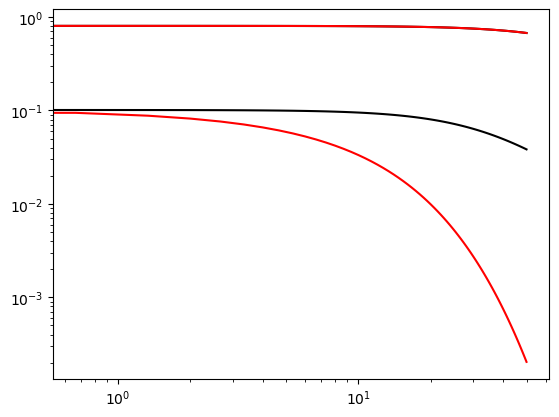

In [8]:
t = 1
Q = 500
alpha = 6000


dist = np.array([1, 100000.0])

S = s0[:2,:]

Sq = S * np.exp(-np.pi * f * t / Q)

St = S.T * np.exp(-2*np.pi*f[:, None]*dist[None,:]/(2*alpha*Q))

plt.figure()
plt.plot(f, S.T, c='k')
plt.plot(f, St, c='r')
# plt.plot(f, Sq.T, c='b')

plt.xscale('log')
plt.yscale('log')
plt.show()



In [9]:
        'syr'           = 0000, 
        'smon'          = 0, 
        'sdy'           = 0, 
        'shr'           = 0, 
        'smn'           = 0, 
        'compazi'       = , 
        'compang'       = , 
        'gain'          = , 
        'f1'            = , 
        'f2'            = , 
        'dt'            = , 
        'ssc'           = 0, 
        'tdif'          = , 
        'slat'          = , 
        'slon'          = , 
        'selev'         = , 
        'deldist'       = , 
        'sazi'          = , 
        'qazi'          = , 
        'pick1'         = , 
        'pick2'         = , 
        'pick3'         = , 
        'pick4'         = , 

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (3018408896.py, line 1)